# Import Librairie

In [147]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from IPython.display import display
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "whitegrid", context = "notebook", palette = "bright")

1) Chargement des jeux de données

    a- Import des données

In [148]:
# Annonces Locations
df_rent = pd.read_csv("D:/Data Scientist/Projet Compagne Immo/ech_annonces_locations_68.csv",sep=";",index_col=0)
df_rent_initial = df_rent.copy()

# Annonces Ventes
df_sale = pd.read_csv("D:/Data Scientist/Projet Compagne Immo/ech_annonces_ventes_68.csv",sep=";",index_col=0)
df_sale_initial = df_sale.copy()

       b- Visualisation des jeux de données

In [149]:
print("=> Echantillon DB : Annonces Locations")
display(df_rent.sample(5))

print("=> Echantillon DB : Annonces Ventes")
display(df_sale.sample(5))

=> Echantillon DB : Annonces Locations


,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,prix_terrain,...,date,INSEE_COM,IRIS,CODE_IRIS,TYP_IRIS_x,TYP_IRIS_y,GRD_QUART,UU2010,REG,DEP
idannonce,,,,,,,,,,,,,,,,,,,,,
ag680824-334020381,pr,m,l,0,80,7.0,5,950,NaN,NaN,...,2022-02,68163,0,681630000,Z,Z,6816300,68205,44,68
ag681106-377684971,pr,m,l,0,95,15.0,5,757,NaN,NaN,...,2023-03,68028,0,680280000,Z,Z,6802800,68000,44,68
ag753633-328164705,pr,a,l,0,100,NaN,4,965,NaN,NaN,...,2022-01,68278,105,682780105,H,H,6827801,68701,44,68
guy-hoquet-immo-facile-2184360,pr,a,l,0,54,NaN,3,500,NaN,NaN,...,2021-09,68224,1602,682241602,H,H,6822401,68701,44,68
155130717,pr,a,l,3,44,NaN,1,586,NaN,NaN,...,2020-01,68063,101,680630101,H,H,6806301,68402,44,68


=> Echantillon DB : Annonces Ventes


,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,prix_terrain,...,UU2010,REG,DEP,loyer_m2_median_n6,nb_log_n6,taux_rendement_n6,loyer_m2_median_n7,nb_log_n7,taux_rendement_n7,prix_m2_vente
idannonce,,,,,,,,,,,,,,,,,,,,,
hektor-agcinqpattes-46,pr,a,v,1,71,NaN,3,235000,NaN,NaN,...,68701,44,68,10.80,6.0,0.039,10.38,31.0,0.038,3309.86
orpi-1-054036E2EK07,pr,a,v,1,57,NaN,2,139400,NaN,NaN,...,68501,44,68,11.45,19.0,0.056,11.45,19.0,0.056,2445.61
ag681119-302412881,pr,a,v,1,75,NaN,3,187000,NaN,NaN,...,68701,44,68,10.22,58.0,0.049,10.00,839.0,0.048,2493.33
ag671791-296561469,pr,a,v,3,44,NaN,2,185000,NaN,NaN,...,68501,44,68,12.73,13.0,0.036,12.08,562.0,0.034,4204.55
mgc-334062695-C-ISS-530-B-AG,pr,m,v,0,122,527.0,5,440000,NaN,NaN,...,68401,44,68,10.46,2.0,0.035,10.46,2.0,0.035,3606.56


2. Premières informations des Jeux de données

             a) Création Fonction "First Data"

In [150]:
def first_data(df):
    return print("\n - Nbr lines :", len(df),
                 "\n - Nbr Variables :", len(df.columns),
                 "\n - Nbr variables catégorielles :", len(df.select_dtypes(include=['object', 'string', 'category']).columns),
                 "\n - Nbr variables numériques :", len(df.select_dtypes(include=["int64","float64"]).columns),
                 "\n - Nbr doublons :", df.duplicated().sum(),
                 "\n - Nbr de NaN :", df.isna().sum().sum(),
                 "\n")

            b) Affichage des First Data

In [151]:
print("=> DB Annonces Locations")
first_data(df_rent)

=> DB Annonces Locations

 - Nbr lines : 11702 
 - Nbr Variables : 51 
 - Nbr variables catégorielles : 20 
 - Nbr variables numériques : 31 
 - Nbr doublons : 0 
 - Nbr de NaN : 177217 



In [152]:
print("=> DB : Annonces Ventes")
first_data(df_sale)

=> DB : Annonces Ventes

 - Nbr lines : 27737 
 - Nbr Variables : 58 
 - Nbr variables catégorielles : 21 
 - Nbr variables numériques : 37 
 - Nbr doublons : 0 
 - Nbr de NaN : 461438 



            C) Création Fonction "Var_Summary" : Tableau résumé des infos variables

In [153]:
def Var_Summary(df):
    table = pd.DataFrame(
        index=df.columns,
        columns=['type_info', 'nb_unique_values','%_NA'])
    table['type_info'] = df.dtypes.values
    table['%_NA'] = (df.isna().sum().values / len(df)*100).round(2)
    table['nb_unique_values'] = df.nunique().values
    return table

            d) Affichage des Tableaux résumé des infos variables par jeu de données

In [154]:
print("\n - DB Annonces Locations : Résumé Varialbes")
Var_Summary(df_rent)


 - DB Annonces Locations : Résumé Varialbes


,type_info,nb_unique_values,%_NA
type_annonceur,object,2,0.00
typedebien,object,3,0.00
typedetransaction,object,2,0.00
etage,int64,26,0.00
surface,int64,204,0.00
surface_terrain,float64,298,95.67
nb_pieces,int64,11,0.00
prix_bien,int64,888,0.00
prix_maison,float64,0,100.00
prix_terrain,float64,0,100.00


In [155]:
# Variable à supprimer :
df_var_rent = Var_Summary(df_rent)
var_rent_delate =df_var_rent[df_var_rent["%_NA"]>50]
print("\n => DB Annonces Location : Variables à supprimer")
display(var_rent_delate)
print("\n => DB Annonces Location : les Variables à supprimer représentent",round((var_rent_delate.shape[0]/df_rent.shape[1]*100),2),"% des variables existantes")


 => DB Annonces Location : Variables à supprimer


,type_info,nb_unique_values,%_NA
surface_terrain,float64,298,95.67
prix_maison,float64,0,100.00
prix_terrain,float64,0,100.00
parking,float64,0,100.00
places_parking,float64,19,65.12
cave,object,2,57.30
annee_construction,float64,128,80.56
nb_toilettes,float64,9,59.06
nb_terraces,float64,4,86.63
videophone,object,2,95.64



 => DB Annonces Location : les Variables à supprimer représentent 31.37 % des variables existantes


In [156]:
print("\n - Annonces Ventes : Résumé Varialbes")
Var_Summary(df_sale)


 - Annonces Ventes : Résumé Varialbes


,type_info,nb_unique_values,%_NA
type_annonceur,object,1,0.00
typedebien,object,5,0.00
typedetransaction,object,3,0.00
etage,int64,24,0.00
surface,int64,398,0.00
surface_terrain,float64,2097,58.74
nb_pieces,int64,22,0.00
prix_bien,int64,5069,0.00
prix_maison,float64,313,98.42
prix_terrain,float64,211,98.42


In [157]:
# Variable à supprimer :
df_var_sale = Var_Summary(df_sale)
var_sale_delate =df_var_sale[df_var_sale["%_NA"]>50]
print("\n => DB Annonces Ventes : Variables à supprimer")
display(var_sale_delate)
print("\n => DB Annonces Ventes : les Variables à supprimer représentent",round((var_sale_delate.shape[0]/df_sale.shape[1]*100),2),"% des variables existantes")


 => DB Annonces Ventes : Variables à supprimer


,type_info,nb_unique_values,%_NA
surface_terrain,float64,2097,58.74
prix_maison,float64,313,98.42
prix_terrain,float64,211,98.42
parking,object,2,99.90
places_parking,float64,22,63.34
cave,object,2,52.24
annee_construction,float64,245,65.90
nb_terraces,float64,9,85.22
videophone,object,2,99.51
porte_digicode,object,2,84.63



 => DB Annonces Ventes : les Variables à supprimer représentent 29.31 % des variables existantes


3- Analyse des Variables : 

            - Numériques vs Catégorielles
            - Matrice de corrélations
            A établir 

4- Analyse Graphique des Variables

            a) Variables Catégorielles :

- Variable 'Type de bien'



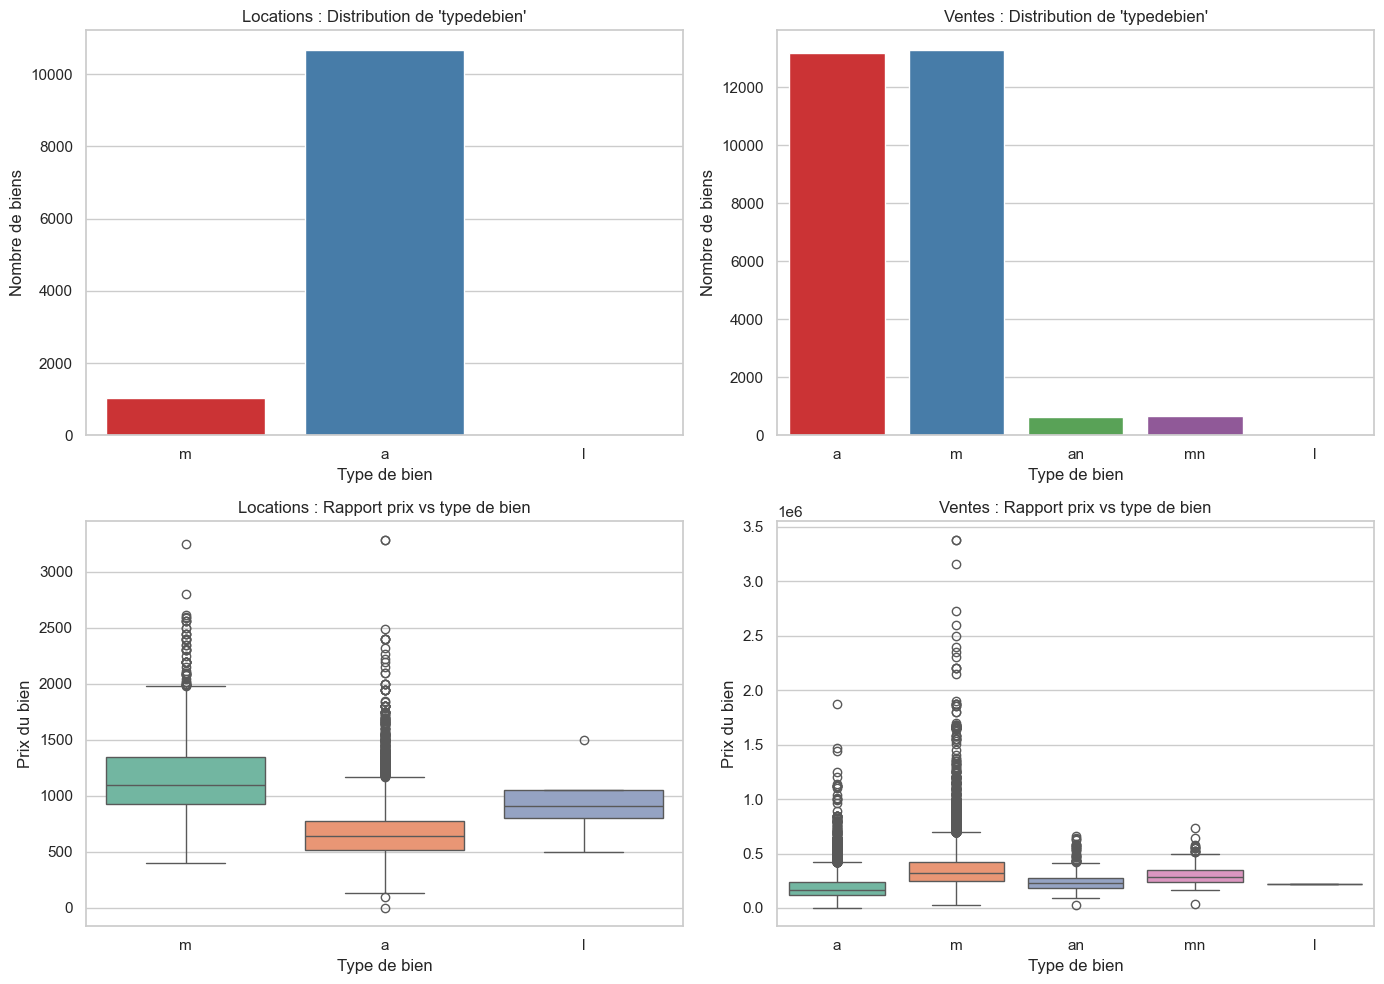

In [158]:
print("- Variable 'Type de bien'\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Locations - Distribution de typedebien
sns.countplot(x='typedebien', data=df_rent, palette='Set1', ax=axes[0,0])
axes[0,0].set_title("Locations : Distribution de 'typedebien'", fontsize=12)
axes[0,0].set_xlabel("Type de bien")
axes[0,0].set_ylabel("Nombre de biens")


# Locations - Rapport prix et type de bien
sns.boxplot(x='typedebien', y='prix_bien', data=df_rent, palette='Set2', ax=axes[1,0])
axes[1,0].set_title("Locations : Rapport prix vs type de bien", fontsize=12)
axes[1,0].set_xlabel("Type de bien")
axes[1,0].set_ylabel("Prix du bien")


# Ventes - Distribution de typedebien
sns.countplot(x='typedebien', data=df_sale, palette='Set1', ax=axes[0,1])
axes[0,1].set_title("Ventes : Distribution de 'typedebien'", fontsize=12)
axes[0,1].set_xlabel("Type de bien")
axes[0,1].set_ylabel("Nombre de biens")


# Ventes - Rapport prix et type de bien
sns.boxplot(x='typedebien', y='prix_bien', data=df_sale, palette='Set2', ax=axes[1,1])
axes[1,1].set_title("Ventes : Rapport prix vs type de bien", fontsize=12)
axes[1,1].set_xlabel("Type de bien")
axes[1,1].set_ylabel("Prix du bien")


plt.tight_layout()
plt.show()

- Variable 'Surface'



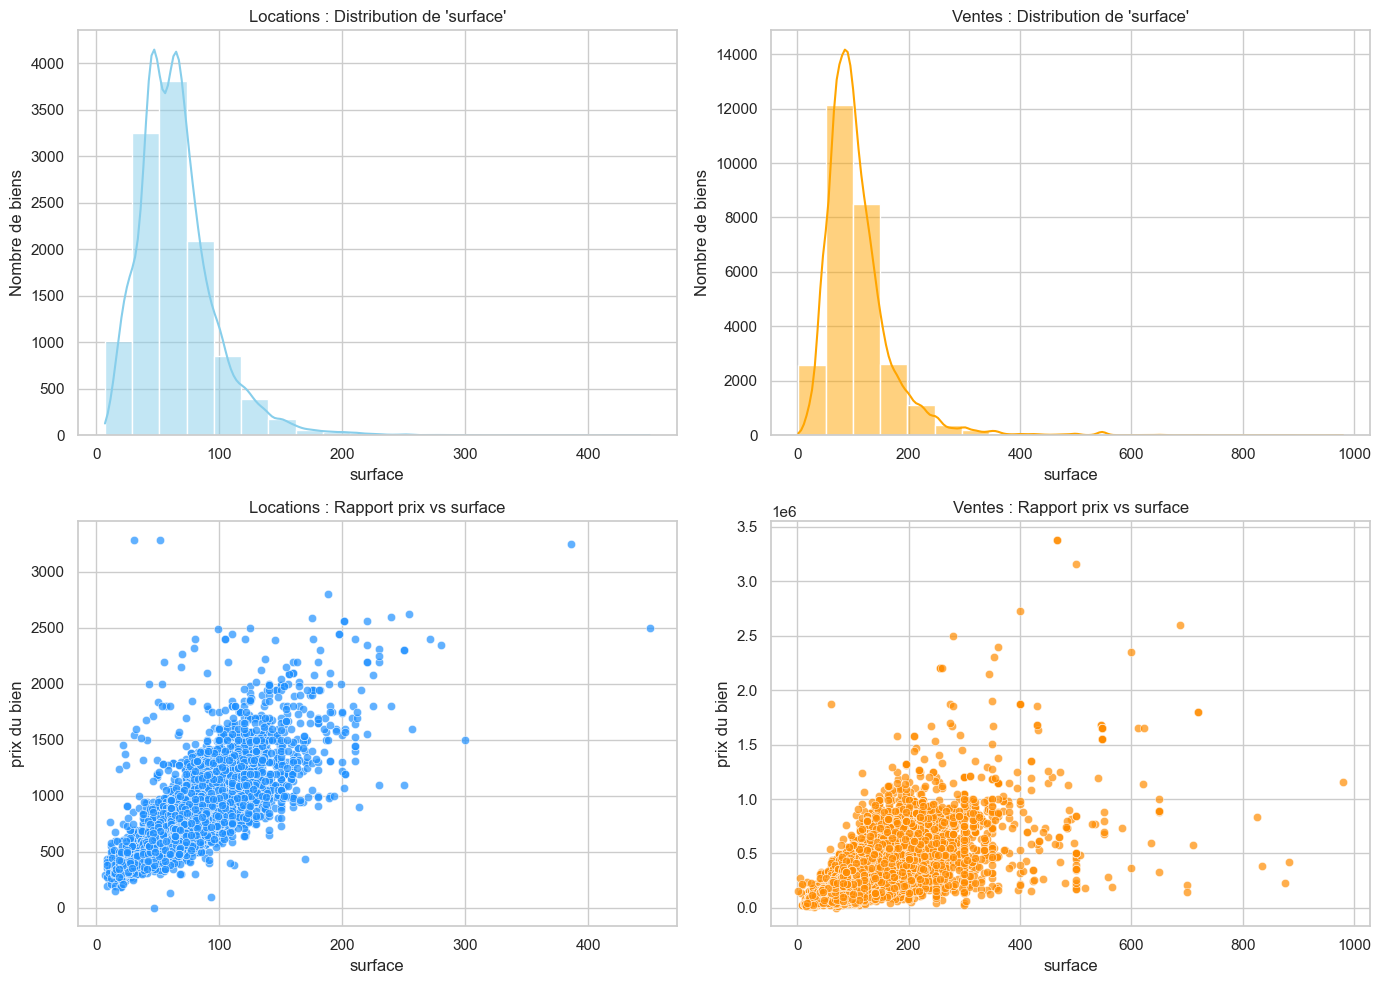

In [159]:
print("- Variable 'Surface'\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Locations - Distribution de surface
sns.histplot(df_rent['surface'], ax=axes[0,0], kde=True, color='skyblue', bins=20)
axes[0,0].set_title("Locations : Distribution de 'surface'", fontsize=12)
axes[0,0].set_xlabel("surface")
axes[0,0].set_ylabel("Nombre de biens")

# Locations - Rapport prix et surface
sns.scatterplot(x='surface', y='prix_bien', data=df_rent, ax=axes[1,0], color='dodgerblue', alpha=0.7)
axes[1,0].set_title("Locations : Rapport prix vs surface", fontsize=12)
axes[1,0].set_xlabel("surface")
axes[1,0].set_ylabel("prix du bien")

# Ventes - Distribution de surface
sns.histplot(df_sale['surface'], ax=axes[0,1], kde=True, color='orange', bins=20)
axes[0,1].set_title("Ventes : Distribution de 'surface'", fontsize=12)
axes[0,1].set_xlabel("surface")
axes[0,1].set_ylabel("Nombre de biens")

# Ventes - Rapport prix et surface
sns.scatterplot(x='surface', y='prix_bien', data=df_sale, ax=axes[1,1], color='darkorange', alpha=0.7)
axes[1,1].set_title("Ventes : Rapport prix vs surface", fontsize=12)
axes[1,1].set_xlabel("surface")
axes[1,1].set_ylabel("prix du bien")

plt.tight_layout()
plt.show()